# Handwritten Digit Classifier

Train a small neural network to recognize handwritten digits from **0 to 9**. We will load MNIST, inspect and prepare the images, train a model, evaluate its mistakes, and predict one digit.

**Level:** Beginner · **Typical local runtime:** about 2 minutes on a standard CPU

All code, explanations, and data used by this project are included in this repository.

## 1. Set up the notebook

Google Colab already includes TensorFlow, NumPy, and Matplotlib. We also fix random seeds so repeated runs are as consistent as possible. Local users can install the dependencies with `pip install tensorflow numpy matplotlib`.

In [1]:
from pathlib import Path
import os
import random

os.environ["TF_DETERMINISTIC_OPS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
NumPy: 2.5.3


## 2. Load MNIST

MNIST is loaded directly from TensorFlow/Keras. Each image is 28 × 28 pixels, and each label is the correct digit.

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:    ", x_test.shape)
print("Pixel range:    ", x_train_full.min(), "to", x_train_full.max())

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images:     (10000, 28, 28)
Pixel range:     0 to 255


## 3. Look at the data

A quick visual check confirms that the images and labels match. The examples are selected with the fixed seed.

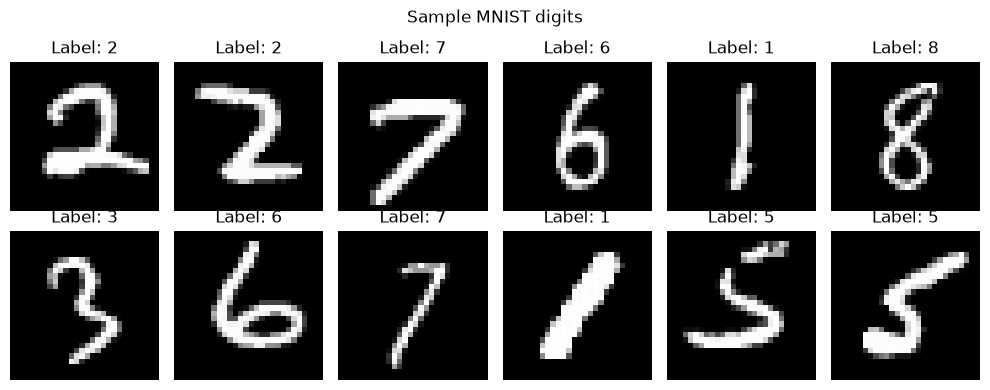

In [3]:
sample_ids = np.random.default_rng(SEED).choice(len(x_train_full), size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image_id in zip(axes.flat, sample_ids):
    ax.imshow(x_train_full[image_id], cmap="gray")
    ax.set_title(f"Label: {y_train_full[image_id]}")
    ax.axis("off")
plt.suptitle("Sample MNIST digits")
plt.tight_layout()
plt.show()

## 4. Prepare the pixels

Pixel values start between 0 and 255. Dividing by 255 scales them to 0–1, which helps the network train smoothly. We also reserve 10,000 training images for validation.

In [4]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

validation_size = 10_000
indices = np.random.default_rng(SEED).permutation(len(x_train_full))
val_ids = indices[:validation_size]
train_ids = indices[validation_size:]

x_train, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val, y_val = x_train_full[val_ids], y_train_full[val_ids]

print("Train set:     ", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:      ", x_test.shape, y_test.shape)

Train set:      (50000, 28, 28) (50000,)
Validation set: (10000, 28, 28) (10000,)
Test set:       (10000, 28, 28) (10000,)


## 5. Build the neural network

`Flatten` turns each 28 × 28 image into 784 numbers. A hidden layer learns useful patterns, while the final 10 outputs represent the digit classes.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

The model sees the training set five times. Validation metrics show how well it performs on images it does not train on.

In [6]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=2,
)

Epoch 1/5


E0000 00:00:1789122365.772811 4074700 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


391/391 - 1s - 2ms/step - accuracy: 0.8774 - loss: 0.4319 - val_accuracy: 0.9349 - val_loss: 0.2353


Epoch 2/5


391/391 - 0s - 772us/step - accuracy: 0.9395 - loss: 0.2088 - val_accuracy: 0.9521 - val_loss: 0.1713


...

391/391 - 0s - 768us/step - accuracy: 0.9529 - loss: 0.1619 - val_accuracy: 0.9624 - val_loss: 0.1389


Epoch 4/5


391/391 - 0s - 764us/step - accuracy: 0.9618 - loss: 0.1312 - val_accuracy: 0.9659 - val_loss: 0.1213


Epoch 5/5


391/391 - 0s - 767us/step - accuracy: 0.9675 - loss: 0.1105 - val_accuracy: 0.9699 - val_loss: 0.1084


## 7. Plot the learning curves

Accuracy should rise while loss falls. A large gap between training and validation results can signal overfitting.

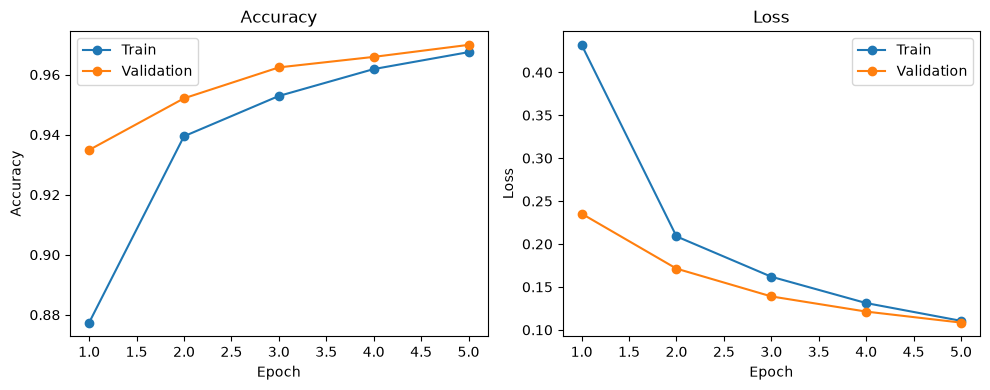

In [7]:
epochs = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs, history.history["accuracy"], marker="o", label="Train")
axes[0].plot(epochs, history.history["val_accuracy"], marker="o", label="Validation")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], marker="o", label="Train")
axes[1].plot(epochs, history.history["val_loss"], marker="o", label="Validation")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate the test set

Test accuracy gives one overall score. The confusion matrix gives more detail: rows are true digits and columns are predicted digits.

Test loss:     0.0957
Test accuracy: 97.24%


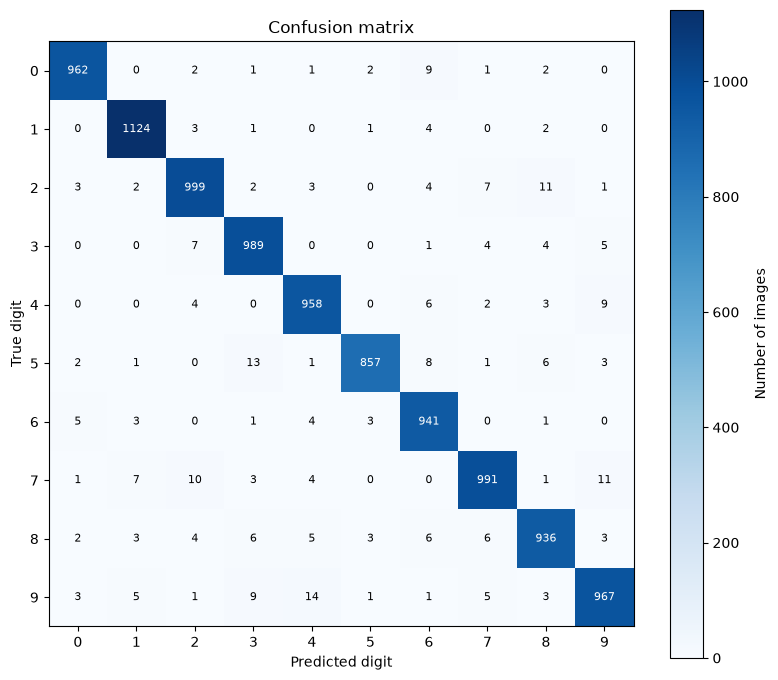

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
test_probabilities = model.predict(x_test, batch_size=256, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
confusion = tf.math.confusion_matrix(y_test, test_predictions, num_classes=10).numpy()

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(confusion, cmap="Blues")
ax.set(
    title="Confusion matrix",
    xlabel="Predicted digit",
    ylabel="True digit",
    xticks=range(10),
    yticks=range(10),
)
threshold = confusion.max() / 2
for true_digit in range(10):
    for predicted_digit in range(10):
        count = confusion[true_digit, predicted_digit]
        ax.text(
            predicted_digit,
            true_digit,
            count,
            ha="center",
            va="center",
            color="white" if count > threshold else "black",
            fontsize=8,
        )
fig.colorbar(image, ax=ax, label="Number of images")
plt.tight_layout()
plt.show()

## 9. Inspect sample predictions

Green titles are correct; red titles are mistakes. Looking at examples makes the accuracy score easier to interpret.

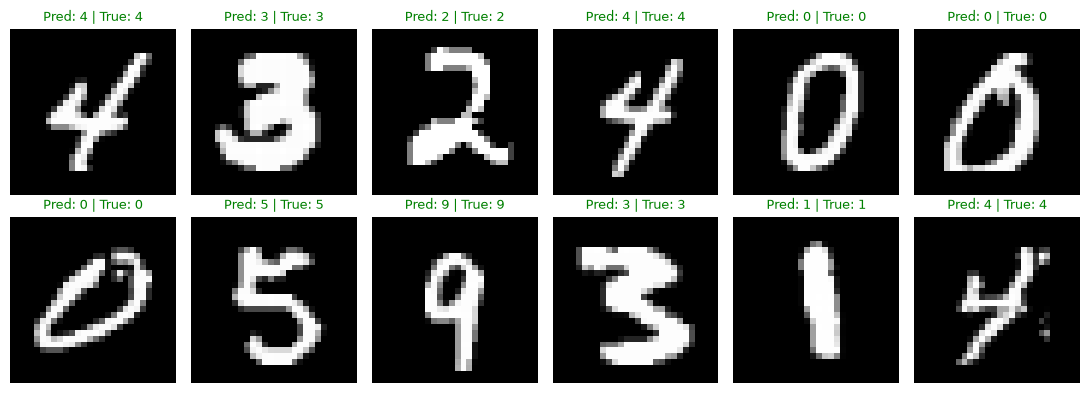

In [9]:
prediction_ids = np.random.default_rng(SEED + 1).choice(len(x_test), size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, image_id in zip(axes.flat, prediction_ids):
    predicted = test_predictions[image_id]
    actual = y_test[image_id]
    color = "green" if predicted == actual else "red"
    ax.imshow(x_test[image_id], cmap="gray")
    ax.set_title(f"Pred: {predicted} | True: {actual}", color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Predict one digit

For one image, the model returns 10 probabilities. The tallest bar is its chosen digit. Change `example_index` to try another test image.

Predicted digit: 9
True digit:      9
Confidence:      98.97%


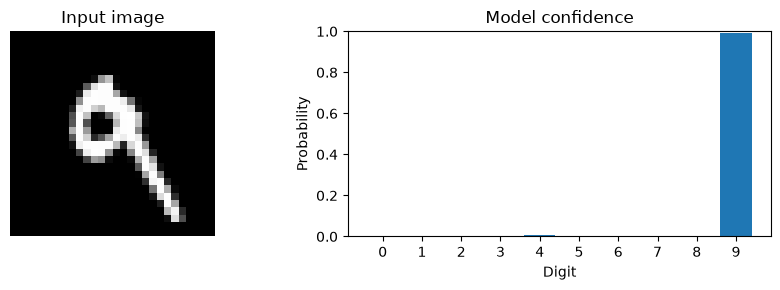

In [10]:
example_index = 7
one_image = x_test[example_index : example_index + 1]
probabilities = model.predict(one_image, verbose=0)[0]
predicted_digit = int(np.argmax(probabilities))

print(f"Predicted digit: {predicted_digit}")
print(f"True digit:      {y_test[example_index]}")
print(f"Confidence:      {probabilities[predicted_digit]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(one_image[0], cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")
axes[1].bar(range(10), probabilities)
axes[1].set(title="Model confidence", xlabel="Digit", ylabel="Probability", xticks=range(10))
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Optional: train for longer

The quick baseline is enough for the demo. To experiment, set the flag below to `True` and run the cell after the baseline training. It adds five epochs and therefore takes longer.

In [11]:
RUN_OPTIONAL_TRAINING = False

if RUN_OPTIONAL_TRAINING:
    model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=5,
        batch_size=128,
        verbose=2,
    )
    _, longer_accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test accuracy after extra training: {longer_accuracy:.2%}")
else:
    print("Optional training skipped. Set RUN_OPTIONAL_TRAINING = True to run it.")

Optional training skipped. Set RUN_OPTIONAL_TRAINING = True to run it.


## Try next

Change the hidden-layer size, compare one and five epochs, or replace the dense network with a convolutional neural network (CNN). Keep the test set untouched until final evaluation.